In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

In [68]:
df=pd.read_csv("Day5_Loan_Prediction_Data(1).csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [69]:
df.shape

(614, 13)

In [70]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [71]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [72]:
df=df.dropna()

In [73]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [74]:
df.shape

(480, 13)

<Axes: xlabel='Property_Area', ylabel='count'>

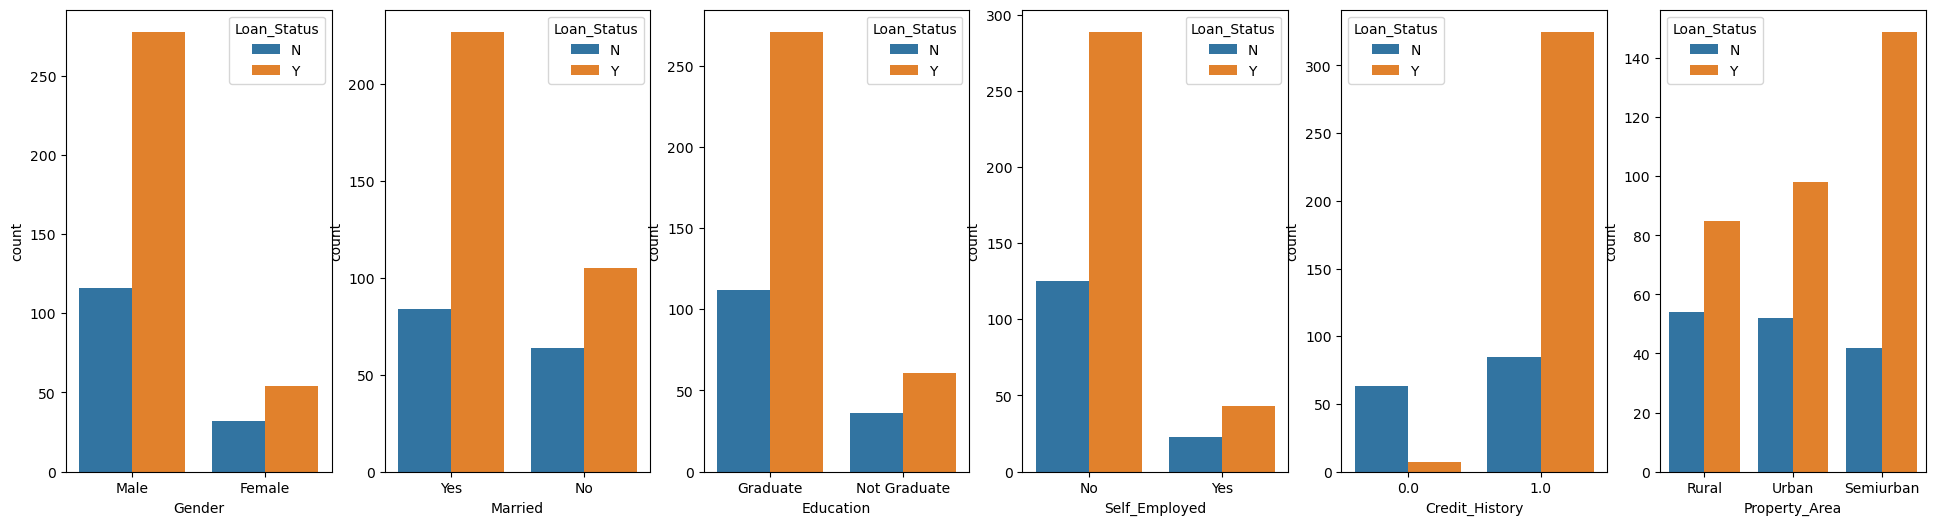

In [75]:
plt.figure(figsize=(24,6))
plt.subplot(1,6,1)
sns.countplot(x='Gender',hue='Loan_Status',data=df)
plt.subplot(1,6,2)
sns.countplot(x='Married',hue='Loan_Status',data=df)
plt.subplot(1,6,3)
sns.countplot(x='Education',hue='Loan_Status',data=df)
plt.subplot(1,6,4)
sns.countplot(x='Self_Employed',hue='Loan_Status',data=df)
plt.subplot(1,6,5)
sns.countplot(x='Credit_History',hue='Loan_Status',data=df)
plt.subplot(1,6,6)
sns.countplot(x='Property_Area',hue='Loan_Status',data=df)


<Axes: xlabel='LoanAmount', ylabel='Count'>

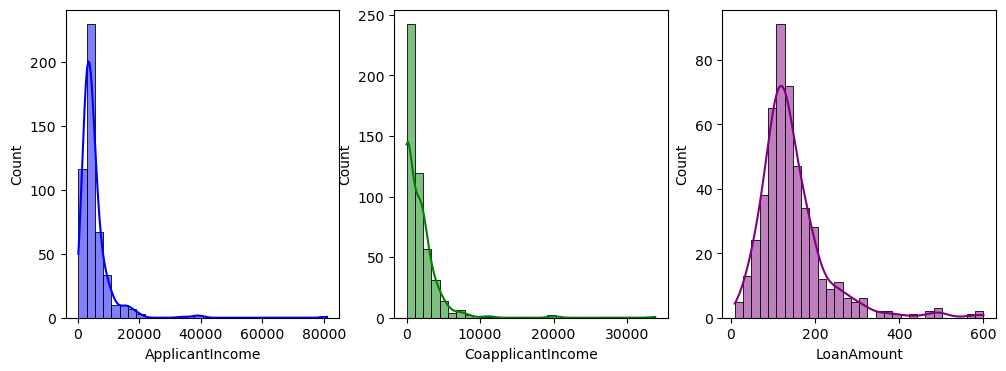

In [76]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
sns.histplot(df['ApplicantIncome'],kde=True,bins=30,color='blue')
plt.subplot(1,3,2)
sns.histplot(df['CoapplicantIncome'],kde=True,bins=30,color='green')
plt.subplot(1,3,3)
sns.histplot(df['LoanAmount'],kde=True,bins=30,color='purple')

In [77]:
le=LabelEncoder()
for col in ['Gender','Married','Education','Self_Employed','Property_Area','Dependents','Loan_Status']:
    df[col]=le.fit_transform(df[col])

C:\Users\admin\AppData\Local\Temp\ipykernel_3164\1333400412.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col]=le.fit_transform(df[col])
C:\Users\admin\AppData\Local\Temp\ipykernel_3164\1333400412.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col]=le.fit_transform(df[col])
C:\Users\admin\AppData\Local\Temp\ipykernel_3164\1333400412.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

In [78]:
x=df.drop(['Loan_ID','Loan_Status'],axis=1)
y=df['Loan_Status']

In [79]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [80]:
model=RandomForestClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

In [81]:
pre=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

y_pred_class=[1 if val >= 0.5 else 0 for val in y_pred]
accuracy=accuracy_score(y_test,y_pred_class)


In [82]:
print("Precision Score:",round(pre,2))
print("Recall Score :",round(recall,2))
print("F1 Score :",round(f1,2))
print("Accuracy :",round(accuracy*100,2),"%")

Precision Score: 0.81
Recall Score : 0.96
F1 Score : 0.88
Accuracy : 81.25 %


In [66]:
gender=int(input())
married=int(input())
dependents=int(input())
education=int(input())
self_employed=int(input())
applicant_income=float(input())
coapplicant_income=float(input())
loan_amount=float(input())
loan_amount_term=float(input())
credit_history=float(input())
property_area=int(input())

new_applicant=pd.DataFrame([[gender,married,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,property_area]],columns=x.columns)
new_pred=model.predict(new_applicant)
if new_pred[0]==1:
    print("Eligible")
else:
    print("Not Eligible")

 1
 0
 0
 0
 0
 6000
 0
 141
 360
 1
 2


Eligible
